In [36]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp


# Estimate effect size via bootstrapping thresholds

Done in `human_loc_power_analysis.py`

In [37]:
import re 
### Load in bootstrap runs:
bootstrap_results = list(Path('human_loc_power_analysis_v2').glob("*.npy"))
print(len(bootstrap_results))
n_samp_splits = {ix:[] for ix in range(3,10)} # 7 max - 2 min 
for file in bootstrap_results:
    if 'subset' not in file.stem:
        continue
    sample_size = int(re.search(r'sample_size_(\d+)_subset', file.stem).group(1))
    # else:
        # sample_size = int(re.search(r'sizes_(\d+)', file.stem).group(1))
    # use re to get integer index from file path in pattern: "sample_size_{ix}_subset"
    # results array is 2d array with shape (n_sample_size_boots, (mean, CI size, upper ci, lower ci))
    bootstrap_results_array = np.load(file).squeeze()
    if bootstrap_results_array.ndim != 2:
        print(file)
        continue
    if len(n_samp_splits[sample_size]) == 0:
        n_samp_splits[sample_size] = bootstrap_results_array
    else:
        n_samp_splits[sample_size] = np.vstack([n_samp_splits[sample_size], bootstrap_results_array])



698


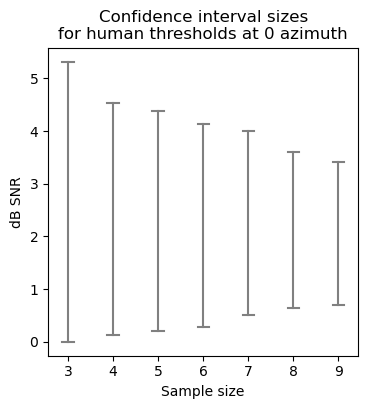

In [38]:
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    data = bootstrap_results_array[:,1]
    ci_means = data.mean()
    # upper_ci = 1.96 * (data.std()/np.sqrt(len(data))) + ci_means
    # lower_ci = ci_means -1.96 * (data.std()/np.sqrt(len(data))) 
    lower_ci, upper_ci = np.nanpercentile(bootstrap_results_array[:,1], [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Confidence interval sizes\nfor human thresholds at 0 azimuth")
plt.xlabel("Sample size")
plt.ylabel("dB SNR")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));

    # axs.plot(sample_size, upper_ci, marker='o')
    # axs.plot(sample_size, mean, marker='o')
    # axs.plot(sample_size, lower_ci, marker='o')
    # plt.errorbar(sample_size, mean,  yerr=upper_ci-lower_ci, alpha=0.3, marker='.')

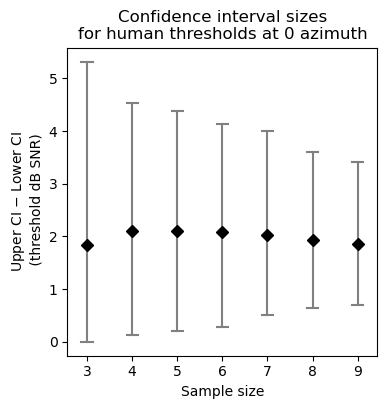

In [39]:
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    ci_means = np.nanmean(bootstrap_results_array[:,1])
    lower_ci, upper_ci = np.nanpercentile(bootstrap_results_array[:,1], [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Confidence interval sizes\nfor human thresholds at 0 azimuth")
plt.xlabel("Sample size")
plt.ylabel("Upper CI $-$ Lower CI\n (threshold dB SNR)")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));

    # axs.plot(sample_size, upper_ci, marker='o')
    # axs.plot(sample_size, mean, marker='o')
    # axs.plot(sample_size, lower_ci, marker='o')
    # plt.errorbar(sample_size, mean,  yerr=upper_ci-lower_ci, alpha=0.3, marker='.')

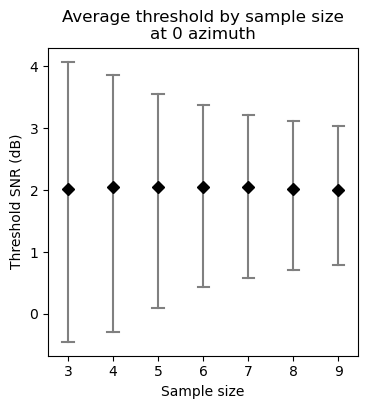

In [40]:
# Plot results 

# sns.set_context('talk')
plt.figure(figsize=(4, 4))
horizontal_line_width=0.25

color = 'grey'

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    ci_means = np.nanmean(bootstrap_results_array[:,0])
    lower_ci, upper_ci = np.nanpercentile(bootstrap_results_array[:,0], [2.5,97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, ci_means, 'D', color='k')

plt.title("Average threshold by sample size\nat 0 azimuth")
plt.xlabel("Sample size")
plt.ylabel("Threshold SNR (dB)")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));


In [41]:
# ## compute threshold for 10 degree azimuth separation

# azim_data = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim==-10)].copy()
# azim_data = azim_data[(azim_data.n_distractors == 2)]
# # azim_data = azim_data[~azim_data.participant.str.contains("6|7|8")]
# # azim_data = azim_data[azim_data.participant != 'participant_001']
# # azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7, 3))]

# azim_results_for_thresh = azim_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()


# azim_10_thresh, fit_popt, _ = util_analysis.estimate_thresholds(azim_results_for_thresh.snr.values, azim_results_for_thresh.correct_mean.values, bounds_from_data=True)
# azim_10_thresh

Text(0.5, 1.0, 'Power as function of\nsample size and SNR difference')

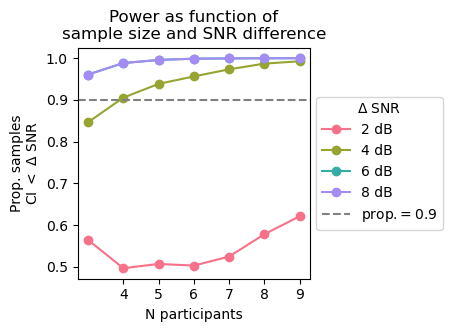

In [42]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB) this is the proportion of trials where the difference in returned confidence intervals is less than or equal to that the SNR
# this means the error in the estimate is small enough to allow for a difference of this magnitude to be reliably measured.  


# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

min_thresholds = list(np.arange(2,10,2)) # dB 

# pick four colors 
colors = sns.color_palette('husl', len(min_thresholds))

samp_sizes = list(n_samp_splits.keys())[1:]
for min_thresh in min_thresholds:   
    props = []
    samps_to_plot = []
    for sample_size, bootstrap_results_array in n_samp_splits.items():
        if len(bootstrap_results_array) == 0:
            continue
        if sample_size == 2:
            continue 
        samps_to_plot.append(sample_size)
        props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))
    plt.plot(samps_to_plot, props,  'o-', color=colors[min_thresholds.index(min_thresh)], label=f"{min_thresh} dB")

    
plt.xlabel("N participants")
plt.ylabel("Prop. samples\nCI $<$ $\Delta$ SNR")
# set x ticks to match sample sizes 
plt.xticks(samp_sizes);
plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')

plt.legend(title='$\Delta$ SNR', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

plt.title(f"Power as function of\nsample size and SNR difference")





In [43]:
min_thresh = 6
# np.where(np.mean(bootstrap_results_array[:,1] < min_thresholds.reshape(-1,1), axis=1) > .9)[0].min(), min_thresholds

[3, 4, 5, 6, 7, 8, 9]


Text(0.5, 1.0, 'Power as function of\nSNR difference and sample size')

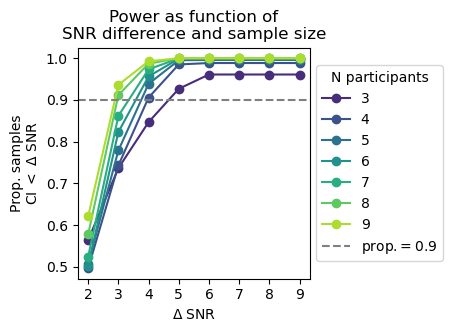

In [45]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB) this is the proportion of trials where the difference in returned confidence intervals is less than or equal to that the SNR
# this means the error in the estimate is small enough to allow for a difference of this magnitude to be reliably measured.  


# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

# pick four colors 

min_thresholds = list(np.arange(2,10)) # dB 
samp_sizes = list(n_samp_splits.keys())
print(samp_sizes)
colors = sns.color_palette('viridis', len(samp_sizes))

for sample_size, bootstrap_results_array in n_samp_splits.items():
    if sample_size == 2:
        continue
    # if len(bootstrap_results_array) == 0:
    #     continue
    props = []
    # n_good_samp_sizes = 0
    for min_thresh in min_thresholds:   
        props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))

    plt.plot(min_thresholds, props,  'o-', color=colors[samp_sizes.index(sample_size)], label=f"{sample_size}")

    
plt.xlabel("$\Delta$ SNR")
plt.ylabel("Prop. samples\nCI $<$ $\Delta$ SNR")
# set x ticks to match sample sizes 
plt.xticks(min_thresholds);
plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')
plt.legend(title='N participants', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

plt.title(f"Power as function of\nSNR difference and sample size")





In [46]:
n_samp_splits.keys()

dict_keys([3, 4, 5, 6, 7, 8, 9])

[3, 4, 5, 6, 7, 8, 9]


(0.0, 7.0)

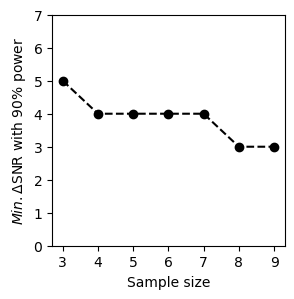

In [57]:
### Compute proporition of times given detectability is within a given snr

# for a given SNR (e.g. 2dB) this is the proportion of trials where the difference in returned confidence intervals is less than or equal to that the SNR
# this means the error in the estimate is small enough to allow for a difference of this magnitude to be reliably measured.  


# for each sample size, compute the proportion of times the difference in the confidence interval is greater than the SNR threshold 
plt.figure(figsize=(3, 3))

# pick four colors 

min_thresholds = np.arange(2,10) # dB 
samp_sizes = list(n_samp_splits.keys())
print(samp_sizes)
colors = sns.color_palette('viridis', len(samp_sizes))
power_level = 0.9 # 90% power 

props = []
for sample_size, bootstrap_results_array in n_samp_splits.items():
    if sample_size == 2:
        continue
    # if len(bootstrap_results_array) == 0:
    #     continue
    # props = []
    # n_good_samp_sizes = 0
    # find min threshold where 90% of samples are below that threshold
    snr_ix = np.where(np.mean(bootstrap_results_array[:,1] < min_thresholds.reshape(-1,1), axis=1) > power_level)[0].min()
    min_thresh = min_thresholds[snr_ix]
    props.append(min_thresh)

    # for min_thresh in min_thresholds:   
        # props.append(np.mean(bootstrap_results_array[:,1] < min_thresh))

plt.plot(samp_sizes, props,  'o--', color='k', label=f"{sample_size}")

    
plt.xlabel("Sample size")
plt.ylabel(f"$Min. \Delta$SNR with {power_level:.0%} power")
# set x ticks to match sample sizes 
plt.xticks(samp_sizes);
plt.ylim(0,7)
# plt.axhline(0.9, color='grey', linestyle='--', label='prop.$=0.9$')
# plt.legend(title='N participants', bbox_to_anchor=(1.6, 0.5), loc='center right')
# add legend and move to right side of figure 

# plot y line at 0.9

# plt.title(f"Power as function of\nSNR difference and sample size", y=1.05)





24.0

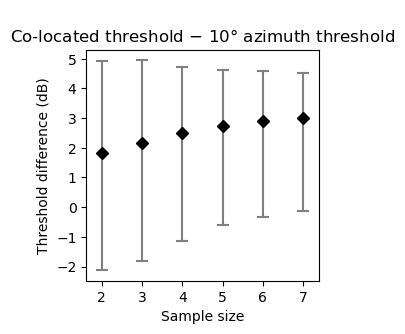

In [78]:
##### Plot difference between estimated 0 azim threshold and population 10 azim threshold 

# azim_data = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim==10)].copy()
# azim_data = azim_data[(azim_data.n_distractors == 2)]
# # azim_data = azim_data[~azim_data.participant.str.contains("6|7|8")]
# # azim_data = azim_data[azim_data.participant != 'participant_001']
# azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7, 3))]

# azim_results_for_thresh = azim_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()

# azim_10_thresh, fit_popt, _ = util_analysis.estimate_thresholds(azim_results_for_thresh.snr.values, azim_results_for_thresh.correct_mean.values, bounds_from_data=True)
# azim_10_thresh

azim_10_thresh = -2.096
plt.figure(figsize=(3, 3))

horizontal_line_width=0.25


for sample_size, bootstrap_results_array in n_samp_splits.items():
    if len(bootstrap_results_array) == 0:
        continue
    # sample 0 azim threshold  - pop 10 azim threshold 
    diffs = bootstrap_results_array[:, 1] 
    mean_diff = np.mean(diffs)
    lower_ci, upper_ci = np.percentile(diffs, [2.5, 97.5])

    left = sample_size - horizontal_line_width / 2
    right = sample_size + horizontal_line_width / 2

    plt.plot([sample_size, sample_size], [upper_ci, lower_ci], color=color)
    plt.plot([left, right], [upper_ci, upper_ci], color=color)
    plt.plot([left, right], [lower_ci, lower_ci], color=color)
    plt.plot(sample_size, mean_diff, 'D', color='k')

plt.title("\nCo-located threshold $-$ 10$\degree$ azimuth threshold")
plt.xlabel("Sample size")
plt.ylabel("Threshold difference (dB)")
# set x ticks to match sample sizes 
plt.xticks(list(n_samp_splits.keys()));


